# Sistema de Análisis del Mercado de Automoción

### Crisitian Cabrera Pinto y Álex Rafael de la Cruz Sánchez

Trabajo SBD y SAA

In [1]:
#Imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
#Lectura de ficheros
df_vehiculos = pd.read_csv('vehiculos.json')
df_ventas_mantenimiento = pd.read_csv('ventas_mantenimiento.csv')
df_opiniones = pd.read_csv('opiniones_clientes.xml')

In [3]:
df_vehiculos.head()

,vehiculo_id,marca,modelo,anio_fabricacion,combustible,transmision,potencia_cv,cilindrada,consumo_urbano,consumo_extraurbano,emisiones_co2,precio_base,segmento
0,VH001,Peugeot,208,2018,Híbrido,Manual,147,1400,6.9,5.5,149,34600,Compacto
1,VH002,Hyundai,i20,2018,Gasolina,Manual,219,2000,4.1,4.1,149,36500,Sedán
2,VH003,Kia,Ev6,2020,Híbrido,Manual,130,2200,5.7,4.3,107,34800,Deportivo
3,VH004,Ford,Puma,2018,Gasolina,Automática,178,2000,5.1,3.6,138,35200,SUV
4,VH005,Hyundai,i20,2022,Gasolina,Automática,237,1400,6.8,3.6,109,38800,SUV


In [4]:
df_ventas_mantenimiento.head()

,venta_id,vehiculo_id,fecha_venta,region_vendedor,precio_venta_real,kilometraje_venta,servicios_realizados,coste_mantenimiento_anual,incidencias_mecanicas,valor_residual_estimado
0,VT001,VH001,2023-03-01,Cataluña,34536,168,0,992,0,12937
1,VT002,VH001,2023-01-24,País Vasco,31929,9835,1,992,0,6894
2,VT003,VH001,2023-10-11,País Vasco,30964,16270,3,992,0,10366
3,VT004,VH002,2023-10-20,Andalucía,31897,44127,0,1030,0,6739
4,VT005,VH003,2023-08-27,Andalucía,34964,20361,2,896,3,18098


In [5]:
df_opiniones.head()

,review_id,vehiculo_id,cliente_id,puntuacion_conjunta,confort,seguridad,eficiencia,diseno,fiabilidad,recomendacion,texto_review
0,RV001,VH204,CUST173,3.4,3.4,3.9,4.8,3.6,3.0,No,"Problemático, poco espacio"
1,RV002,VH249,CUST034,3.0,3.1,3.4,4.1,2.9,2.6,No,"Decepcionante, poco espacio"
2,RV003,VH244,CUST038,5.0,5.0,5.0,5.0,5.0,5.0,Si,"Eficiente vehículo, gran rendimiento"
3,RV004,VH280,CUST022,3.9,3.9,3.9,4.8,3.5,3.1,Si,"Problemático, precio elevado"
4,RV005,VH125,CUST153,4.0,4.2,4.5,4.2,4.1,5.0,Si,"Lento, precio elevado"


### Fase 0: Datos

¿Que datos tiene el fichero de vehiculos?

In [6]:
df_vehiculos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   vehiculo_id          300 non-null    object 
 1   marca                300 non-null    object 
 2   modelo               300 non-null    object 
 3   anio_fabricacion     300 non-null    int64  
 4   combustible          300 non-null    object 
 5   transmision          300 non-null    object 
 6   potencia_cv          300 non-null    int64  
 7   cilindrada           300 non-null    int64  
 8   consumo_urbano       300 non-null    float64
 9   consumo_extraurbano  300 non-null    float64
 10  emisiones_co2        300 non-null    int64  
 11  precio_base          300 non-null    int64  
 12  segmento             300 non-null    object 
dtypes: float64(2), int64(5), object(6)
memory usage: 30.6+ KB


In [7]:
df_vehiculos.shape

(300, 13)

¿Qué datos tiene el fichero de venta y mantenimientos?

In [8]:
df_ventas_mantenimiento.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   venta_id                   600 non-null    object
 1   vehiculo_id                600 non-null    object
 2   fecha_venta                600 non-null    object
 3   region_vendedor            600 non-null    object
 4   precio_venta_real          600 non-null    int64 
 5   kilometraje_venta          600 non-null    int64 
 6   servicios_realizados       600 non-null    int64 
 7   coste_mantenimiento_anual  600 non-null    int64 
 8   incidencias_mecanicas      600 non-null    int64 
 9   valor_residual_estimado    600 non-null    int64 
dtypes: int64(6), object(4)
memory usage: 47.0+ KB


In [9]:
df_ventas_mantenimiento.shape

(600, 10)

¿Qué datos tiene el fichero de opiniones?

In [10]:
df_opiniones.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   review_id            500 non-null    object 
 1   vehiculo_id          500 non-null    object 
 2   cliente_id           500 non-null    object 
 3   puntuacion_conjunta  500 non-null    float64
 4   confort              500 non-null    float64
 5   seguridad            500 non-null    float64
 6   eficiencia           500 non-null    float64
 7   diseno               500 non-null    float64
 8   fiabilidad           500 non-null    float64
 9   recomendacion        500 non-null    object 
 10  texto_review         500 non-null    object 
dtypes: float64(6), object(5)
memory usage: 43.1+ KB


In [11]:
df_opiniones.shape

(500, 11)

### Fase 1: Selección y comprensión del dominio

### Fase 2: Preprocesamiento y limpieza

#### - Integración de múltiples fuentes 

In [12]:
# Unificación de los dataframes
df_ventas_vehiculo = pd.merge(df_ventas_mantenimiento, df_vehiculos, on="vehiculo_id", how="left")

df_ventas_vehiculo.head()

,venta_id,vehiculo_id,fecha_venta,region_vendedor,precio_venta_real,kilometraje_venta,servicios_realizados,coste_mantenimiento_anual,incidencias_mecanicas,valor_residual_estimado,...,anio_fabricacion,combustible,transmision,potencia_cv,cilindrada,consumo_urbano,consumo_extraurbano,emisiones_co2,precio_base,segmento
0,VT001,VH001,2023-03-01,Cataluña,34536,168,0,992,0,12937,...,2018,Híbrido,Manual,147,1400,6.9,5.5,149,34600,Compacto
1,VT002,VH001,2023-01-24,País Vasco,31929,9835,1,992,0,6894,...,2018,Híbrido,Manual,147,1400,6.9,5.5,149,34600,Compacto
2,VT003,VH001,2023-10-11,País Vasco,30964,16270,3,992,0,10366,...,2018,Híbrido,Manual,147,1400,6.9,5.5,149,34600,Compacto
3,VT004,VH002,2023-10-20,Andalucía,31897,44127,0,1030,0,6739,...,2018,Gasolina,Manual,219,2000,4.1,4.1,149,36500,Sedán
4,VT005,VH003,2023-08-27,Andalucía,34964,20361,2,896,3,18098,...,2020,Híbrido,Manual,130,2200,5.7,4.3,107,34800,Deportivo


Para la construcción del dataset unificado, se ha priorizado la integridad transaccional de los datos de ventas.

- Integración Ventas-Vehículos: Se ha realizado una unión (Left Join) entre el histórico de ventas y el catálogo de vehículos. Dado que la cardinalidad es de N:1 (muchas ventas pueden referirse al mismo modelo de coche), esta operación es segura y enriquece cada venta con sus especificaciones técnicas sin alterar el número de registros (600 transacciones).
- Hemos decidido no integrar físicamente la tabla de opiniones en esta fase preliminar. El motivo es la naturaleza "uno a muchos" de las reseñas (un vehículo tiene múltiples opiniones). Una unión directa duplicaría los registros de ventas, introduciendo sesgo en los futuros modelos de predicción de precios. Y si se tratara de unir haciendo medias y modas se perdería el texto de las reseñas.

Trabajaremos con un dataset de ventas y vehiculos para los modelos numéricos y agruparemos con las opiniones en los apartados que requieran de ellas y en las que se requiera.

In [13]:
df_ventas_vehiculo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   venta_id                   600 non-null    object 
 1   vehiculo_id                600 non-null    object 
 2   fecha_venta                600 non-null    object 
 3   region_vendedor            600 non-null    object 
 4   precio_venta_real          600 non-null    int64  
 5   kilometraje_venta          600 non-null    int64  
 6   servicios_realizados       600 non-null    int64  
 7   coste_mantenimiento_anual  600 non-null    int64  
 8   incidencias_mecanicas      600 non-null    int64  
 9   valor_residual_estimado    600 non-null    int64  
 10  marca                      600 non-null    object 
 11  modelo                     600 non-null    object 
 12  anio_fabricacion           600 non-null    int64  
 13  combustible                600 non-null    object 

In [14]:
#Valores realistas
df_ventas_vehiculo.describe()

,precio_venta_real,kilometraje_venta,servicios_realizados,coste_mantenimiento_anual,incidencias_mecanicas,valor_residual_estimado,anio_fabricacion,potencia_cv,cilindrada,consumo_urbano,consumo_extraurbano,emisiones_co2,precio_base
count,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000
mean,34625.320000,26835.851667,3.016667,870.370000,0.463333,21677.175000,2021.211667,179.285000,1475.333333,5.390167,4.530500,105.101667,36547.666667
std,7230.237142,14023.227856,2.038786,173.518137,0.943472,10559.684987,1.954456,53.542461,707.266049,1.773451,1.233189,49.728022,7307.009091
min,21773.000000,55.000000,0.000000,542.000000,0.000000,5340.000000,2018.000000,90.000000,0.000000,1.500000,1.800000,0.000000,25000.000000
25%,29492.250000,14661.000000,1.000000,734.000000,0.000000,13263.750000,2019.000000,134.000000,1200.000000,4.500000,3.900000,92.000000,31150.000000
50%,33160.500000,27763.000000,3.000000,852.000000,0.000000,19264.500000,2021.000000,174.000000,1600.000000,5.600000,4.600000,120.000000,35150.000000
75%,38418.000000,38716.000000,5.000000,992.000000,0.000000,28073.250000,2023.000000,217.000000,2000.000000,6.800000,5.500000,140.000000,39700.000000
max,61242.000000,49936.000000,6.000000,1478.000000,3.000000,58200.000000,2024.000000,336.000000,2200.000000,8.000000,6.500000,160.000000,58900.000000


In [15]:
df_opiniones.describe()

,puntuacion_conjunta,confort,seguridad,eficiencia,diseno,fiabilidad
count,500.00000,500.000000,500.000000,500.00000,500.00000,500.000000
mean,3.75940,3.731000,3.935800,3.75120,3.63300,3.619600
std,0.79785,0.900289,0.850685,0.92802,0.99228,0.918359
min,1.00000,1.000000,1.000000,1.00000,1.00000,1.000000
25%,3.20000,3.200000,3.375000,3.10000,3.00000,2.900000
50%,3.80000,3.800000,4.000000,3.80000,3.70000,3.700000
75%,4.40000,4.400000,4.600000,4.50000,4.40000,4.400000
max,5.00000,5.000000,5.000000,5.00000,5.00000,5.000000


In [16]:
#Comprobación de valores nulos
df_ventas_vehiculo.isnull().sum()

venta_id                     0
vehiculo_id                  0
fecha_venta                  0
region_vendedor              0
precio_venta_real            0
kilometraje_venta            0
servicios_realizados         0
coste_mantenimiento_anual    0
incidencias_mecanicas        0
valor_residual_estimado      0
marca                        0
modelo                       0
anio_fabricacion             0
combustible                  0
transmision                  0
potencia_cv                  0
cilindrada                   0
consumo_urbano               0
consumo_extraurbano          0
emisiones_co2                0
precio_base                  0
segmento                     0
dtype: int64

In [17]:
df_opiniones.isnull().sum()

review_id              0
vehiculo_id            0
cliente_id             0
puntuacion_conjunta    0
confort                0
seguridad              0
eficiencia             0
diseno                 0
fiabilidad             0
recomendacion          0
texto_review           0
dtype: int64

- No se pueden observar valores atípicos y nulos en los dos datasets con los que trabajaremos

#### - Limpieza y tratamiento de valores anomalos

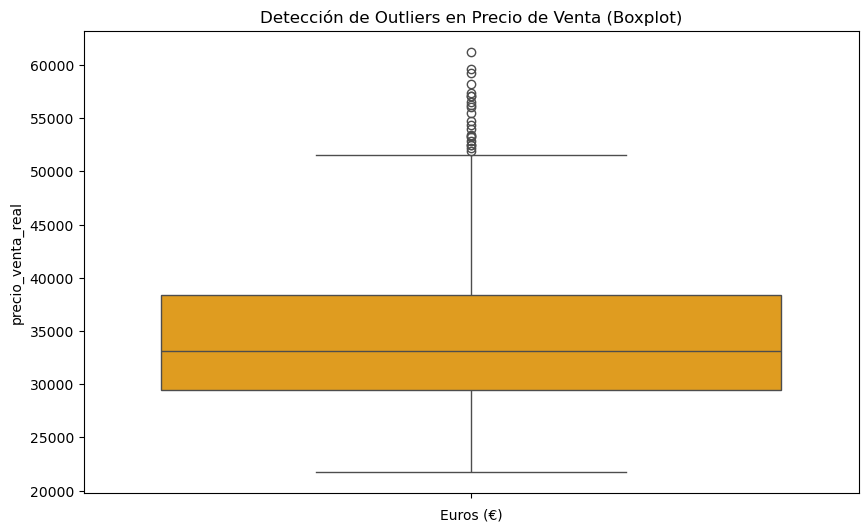

In [18]:
#Analisis de outlier en precio de venta
plt.figure(figsize=(10,6))
sns.boxplot(df_ventas_vehiculo['precio_venta_real'], color='orange')
plt.title('Detección de Outliers en Precio de Venta (Boxplot)')
plt.xlabel('Euros (€)')
plt.show()

Podemos observar que hay precios que superar el valor máximo no atípico. Pero ¿que tipo de vehículos son estos?

In [19]:
# Cálculo numérico del IQR
Q1 = df_ventas_vehiculo['precio_venta_real'].quantile(0.25)
Q3 = df_ventas_vehiculo['precio_venta_real'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR


#Los outliers son:
outliers = df_ventas_vehiculo[df_ventas_vehiculo['precio_venta_real'] > limite_superior]
print("Número de outliers detectados:", outliers.shape[0])
#Mostar marcas y modelos de los outliers
print(outliers[['marca', 'modelo', 'precio_venta_real','segmento']])

Número de outliers detectados: 22
        marca     modelo  precio_venta_real  segmento
28    Renault    Austral              56050       SUV
39        BMW         X1              59659       SUV
40        BMW         X1              61242       SUV
45   Mercedes    Clase E              52516     Sedán
58       Ford       Kuga              54014       SUV
59       Ford       Kuga              53224       SUV
60       Ford       Kuga              58232       SUV
116       Kia       Niro              52883       SUV
117       Kia       Niro              56512       SUV
170   Hyundai      Ionic              53428       SUV
197   Renault  Renault 5              54735     Sedán
206       BMW         X3              56198     Sedán
208    Toyota      Yaris              52191  Compacto
213       Kia       Ceed              55497     Sedán
304       BMW    Serie 3              51911       SUV
358      Ford     Mondeo              52505       SUV
363   Hyundai        i30              54373  Com

Podemos comprobar que se corresponden a vehículos de gama alta, por lo que estos valores no son errores, sino precios legítimos. Eliminarlos sesgaría el modelo, impidiéndole predecir correctamente vehículos de gama alta.

In [20]:
#Validación de cilindrada
cilindrada_cero = df_ventas_vehiculo[df_ventas_vehiculo['cilindrada'] == 0]
print("Número de vehículos con cilindrada cero:", cilindrada_cero.shape[0])


Número de vehículos con cilindrada cero: 93


Hemos podido comprobar que hay vehículos con cilindrada cero, de modo que tenemos que comprobar que todos los vehículos con esta cilindrada sean electricos (puesto que son los únicos que no tienen cilindros) en caso de que haya otro tipo se trataría de un error.

In [21]:
print(cilindrada_cero['combustible'].unique()) # Debería salir solo 'Eléctrico'

['Eléctrico']


Tan solo son coches eléctricos por lo que no hay valores incorrectos

In [22]:
#Validación del consumo medio
consumo_cero_urbano = df_ventas_vehiculo[(df_ventas_vehiculo['consumo_urbano'] <= 0) | (df_ventas_vehiculo['consumo_urbano'] > 20)]
print("Número de vehículos con consumo urbano no realista:", consumo_cero_urbano.shape[0])

consumo_cero_carr = df_ventas_vehiculo[(df_ventas_vehiculo['consumo_extraurbano'] <= 0) | (df_ventas_vehiculo['consumo_extraurbano'] > 20)]
print("Número de vehículos con consumo extraurbano no realista:", consumo_cero_carr.shape[0])

Número de vehículos con consumo urbano no realista: 0
Número de vehículos con consumo extraurbano no realista: 0


No hemos encontrado valores negativos ni consumos imposibles (0 L/100km en coches de combustión o > 20 L/100km) sino que no pasan los consumos más altos de 9 L/100km.

In [23]:
#Comprobación de valores missing en puntuaciones

#Unir dataframes de ventas y opiniones
df_completo = pd.merge(df_ventas_vehiculo, df_opiniones, on="vehiculo_id", how="left")

#Columnas que queremos comprobar
cols_puntuacion = ['puntuacion_conjunta', 'confort', 'seguridad', 
                   'eficiencia', 'diseno', 'fiabilidad']

#Comprobar valores missing
n_ventas_total = len(df_completo)
n_sin_review = df_completo['puntuacion_conjunta'].isnull().sum()
porcentaje_missing = (n_sin_review / n_ventas_total) * 100

print(f"Total de ventas registradas: {n_ventas_total}")
print(f"Ventas sin ninguna opinión de cliente: {n_sin_review}")
print(f"Porcentaje de datos faltantes en puntuaciones: {porcentaje_missing:.2f}%")

#Ver  coche vendidio sin review
print("\nEjemplo de vehículos vendidos sin feedback (Valores Missing):")
missing_reviews = df_completo[df_completo['puntuacion_conjunta'].isnull()]
print(missing_reviews[['vehiculo_id', 'marca', 'modelo', 'puntuacion_conjunta','confort','seguridad','eficiencia','diseno','fiabilidad']].head())

Total de ventas registradas: 1123
Ventas sin ninguna opinión de cliente: 111
Porcentaje de datos faltantes en puntuaciones: 9.88%

Ejemplo de vehículos vendidos sin feedback (Valores Missing):
   vehiculo_id marca modelo  puntuacion_conjunta  confort  seguridad  \
5        VH003   Kia    Ev6                  NaN      NaN        NaN   
6        VH004  Ford   Puma                  NaN      NaN        NaN   
17       VH008  Ford   Puma                  NaN      NaN        NaN   
18       VH008  Ford   Puma                  NaN      NaN        NaN   
19       VH009  Ford   Kuga                  NaN      NaN        NaN   

    eficiencia  diseno  fiabilidad  
5          NaN     NaN         NaN  
6          NaN     NaN         NaN  
17         NaN     NaN         NaN  
18         NaN     NaN         NaN  
19         NaN     NaN         NaN  


Al analizar el fichero origen de opiniones (Opiniones-clientes.xml), no se encontraron valores nulos; sin embargo, al cruzar los datos con las ventas, existen vehículos que no poseen reseñas.

Dado que las opiniones se integrarán dinámicamente en fases posteriores, no se imputarán valores artificiales (como la media) en esta fase para no introducir "ruido".

In [24]:
#Normalización de variables técnicas
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
variables_tecnicas = ['cilindrada', 'potencia_cv']
for var in variables_tecnicas:
    df_ventas_vehiculo[[var + "_normalizado"]] = scaler.fit_transform(df_ventas_vehiculo[[var]])

df_ventas_vehiculo.head()

,venta_id,vehiculo_id,fecha_venta,region_vendedor,precio_venta_real,kilometraje_venta,servicios_realizados,coste_mantenimiento_anual,incidencias_mecanicas,valor_residual_estimado,...,transmision,potencia_cv,cilindrada,consumo_urbano,consumo_extraurbano,emisiones_co2,precio_base,segmento,cilindrada_normalizado,potencia_cv_normalizado
0,VT001,VH001,2023-03-01,Cataluña,34536,168,0,992,0,12937,...,Manual,147,1400,6.9,5.5,149,34600,Compacto,0.636364,0.231707
1,VT002,VH001,2023-01-24,País Vasco,31929,9835,1,992,0,6894,...,Manual,147,1400,6.9,5.5,149,34600,Compacto,0.636364,0.231707
2,VT003,VH001,2023-10-11,País Vasco,30964,16270,3,992,0,10366,...,Manual,147,1400,6.9,5.5,149,34600,Compacto,0.636364,0.231707
3,VT004,VH002,2023-10-20,Andalucía,31897,44127,0,1030,0,6739,...,Manual,219,2000,4.1,4.1,149,36500,Sedán,0.909091,0.524390
4,VT005,VH003,2023-08-27,Andalucía,34964,20361,2,896,3,18098,...,Manual,130,2200,5.7,4.3,107,34800,Deportivo,1.000000,0.162602


Para evitar que variables con escalas grandes (como cilindrada: 1200-2200) dominen sobre variables pequeñas (como consumo: 4-8) en algoritmos basados en distancia (como K-Nearest Neighbors o SVM), se ha aplicado una normalización Min-Max. Si no normalizo, la cilindrada (2000) pesaría mucho más que la potencia (150) simplemente por ser un número más grande, falseando el resultado.

#### - Ingeniería de características

Creación de variables

In [25]:
#Creación de la variable antigüedad
ANIO_ACTUAL = 2026 #Asumo el año actual como 2026

df_ventas_vehiculo['antiguedad'] = ANIO_ACTUAL - df_ventas_vehiculo['anio_fabricacion']

df_ventas_vehiculo.head()


,venta_id,vehiculo_id,fecha_venta,region_vendedor,precio_venta_real,kilometraje_venta,servicios_realizados,coste_mantenimiento_anual,incidencias_mecanicas,valor_residual_estimado,...,potencia_cv,cilindrada,consumo_urbano,consumo_extraurbano,emisiones_co2,precio_base,segmento,cilindrada_normalizado,potencia_cv_normalizado,antiguedad
0,VT001,VH001,2023-03-01,Cataluña,34536,168,0,992,0,12937,...,147,1400,6.9,5.5,149,34600,Compacto,0.636364,0.231707,8
1,VT002,VH001,2023-01-24,País Vasco,31929,9835,1,992,0,6894,...,147,1400,6.9,5.5,149,34600,Compacto,0.636364,0.231707,8
2,VT003,VH001,2023-10-11,País Vasco,30964,16270,3,992,0,10366,...,147,1400,6.9,5.5,149,34600,Compacto,0.636364,0.231707,8
3,VT004,VH002,2023-10-20,Andalucía,31897,44127,0,1030,0,6739,...,219,2000,4.1,4.1,149,36500,Sedán,0.909091,0.524390,8
4,VT005,VH003,2023-08-27,Andalucía,34964,20361,2,896,3,18098,...,130,2200,5.7,4.3,107,34800,Deportivo,1.000000,0.162602,6


In [26]:
#Creación de variable eficiencia global
df_ventas_vehiculo['eficiencia_global'] = (df_ventas_vehiculo['consumo_urbano'] + df_ventas_vehiculo['consumo_extraurbano']) / 2

df_ventas_vehiculo.head()

,venta_id,vehiculo_id,fecha_venta,region_vendedor,precio_venta_real,kilometraje_venta,servicios_realizados,coste_mantenimiento_anual,incidencias_mecanicas,valor_residual_estimado,...,cilindrada,consumo_urbano,consumo_extraurbano,emisiones_co2,precio_base,segmento,cilindrada_normalizado,potencia_cv_normalizado,antiguedad,eficiencia_global
0,VT001,VH001,2023-03-01,Cataluña,34536,168,0,992,0,12937,...,1400,6.9,5.5,149,34600,Compacto,0.636364,0.231707,8,6.2
1,VT002,VH001,2023-01-24,País Vasco,31929,9835,1,992,0,6894,...,1400,6.9,5.5,149,34600,Compacto,0.636364,0.231707,8,6.2
2,VT003,VH001,2023-10-11,País Vasco,30964,16270,3,992,0,10366,...,1400,6.9,5.5,149,34600,Compacto,0.636364,0.231707,8,6.2
3,VT004,VH002,2023-10-20,Andalucía,31897,44127,0,1030,0,6739,...,2000,4.1,4.1,149,36500,Sedán,0.909091,0.524390,8,4.1
4,VT005,VH003,2023-08-27,Andalucía,34964,20361,2,896,3,18098,...,2200,5.7,4.3,107,34800,Deportivo,1.000000,0.162602,6,5.0


In [27]:
#Creación de variable ratio precio/potencia
df_ventas_vehiculo['ratio_precio_potencia'] = df_ventas_vehiculo['precio_base'] / df_ventas_vehiculo['potencia_cv']

df_ventas_vehiculo.head()

,venta_id,vehiculo_id,fecha_venta,region_vendedor,precio_venta_real,kilometraje_venta,servicios_realizados,coste_mantenimiento_anual,incidencias_mecanicas,valor_residual_estimado,...,consumo_urbano,consumo_extraurbano,emisiones_co2,precio_base,segmento,cilindrada_normalizado,potencia_cv_normalizado,antiguedad,eficiencia_global,ratio_precio_potencia
0,VT001,VH001,2023-03-01,Cataluña,34536,168,0,992,0,12937,...,6.9,5.5,149,34600,Compacto,0.636364,0.231707,8,6.2,235.374150
1,VT002,VH001,2023-01-24,País Vasco,31929,9835,1,992,0,6894,...,6.9,5.5,149,34600,Compacto,0.636364,0.231707,8,6.2,235.374150
2,VT003,VH001,2023-10-11,País Vasco,30964,16270,3,992,0,10366,...,6.9,5.5,149,34600,Compacto,0.636364,0.231707,8,6.2,235.374150
3,VT004,VH002,2023-10-20,Andalucía,31897,44127,0,1030,0,6739,...,4.1,4.1,149,36500,Sedán,0.909091,0.524390,8,4.1,166.666667
4,VT005,VH003,2023-08-27,Andalucía,34964,20361,2,896,3,18098,...,5.7,4.3,107,34800,Deportivo,1.000000,0.162602,6,5.0,267.692308


In [28]:
#Variable de categoria de emisiones
def clasificador_emisiones(co2):
    if co2 < 110: return 'Eco'
    elif co2 <= 150: return 'Media'
    else: return 'Contaminante'

df_ventas_vehiculo['categoria_emisiones'] = df_ventas_vehiculo['emisiones_co2'].apply(clasificador_emisiones)

df_ventas_vehiculo.head()

,venta_id,vehiculo_id,fecha_venta,region_vendedor,precio_venta_real,kilometraje_venta,servicios_realizados,coste_mantenimiento_anual,incidencias_mecanicas,valor_residual_estimado,...,consumo_extraurbano,emisiones_co2,precio_base,segmento,cilindrada_normalizado,potencia_cv_normalizado,antiguedad,eficiencia_global,ratio_precio_potencia,categoria_emisiones
0,VT001,VH001,2023-03-01,Cataluña,34536,168,0,992,0,12937,...,5.5,149,34600,Compacto,0.636364,0.231707,8,6.2,235.374150,Media
1,VT002,VH001,2023-01-24,País Vasco,31929,9835,1,992,0,6894,...,5.5,149,34600,Compacto,0.636364,0.231707,8,6.2,235.374150,Media
2,VT003,VH001,2023-10-11,País Vasco,30964,16270,3,992,0,10366,...,5.5,149,34600,Compacto,0.636364,0.231707,8,6.2,235.374150,Media
3,VT004,VH002,2023-10-20,Andalucía,31897,44127,0,1030,0,6739,...,4.1,149,36500,Sedán,0.909091,0.524390,8,4.1,166.666667,Media
4,VT005,VH003,2023-08-27,Andalucía,34964,20361,2,896,3,18098,...,4.3,107,34800,Deportivo,1.000000,0.162602,6,5.0,267.692308,Eco


In [29]:
#Índice de fiabilidad

#Sacar media de fiabilidad por vehiculo id

fiabilidad_media = df_opiniones.groupby('vehiculo_id')['fiabilidad'].mean().reset_index()
fiabilidad_media.rename(columns={'fiabilidad': 'fiabilidad_media'}, inplace=True)

#Unir dataframes principal con fiabilidad media
df = pd.merge(df_ventas_vehiculo, fiabilidad_media, on='vehiculo_id', how='left')

#Tratar valores de coches sin opiniones
media_fiabilidad = df['fiabilidad_media'].mean()
df['fiabilidad_media'].fillna(media_fiabilidad, inplace=True)

#Calcular el índice de fiabilidad: normalizando incidencias y fiabilidad

max_incidencias = df['incidencias_mecanicas'].max()
incidencias_norm = 1 - (df['incidencias_mecanicas'] / max_incidencias)  # Invertido para que menos incidencias sea mejor

fiabilidad_norm = df['fiabilidad_media'] / 5

df['indice_fiabilidad'] = (incidencias_norm + fiabilidad_norm) / 2

df.head()

C:\Users\Ccp0897\AppData\Local\Temp\ipykernel_15340\2846861209.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['fiabilidad_media'].fillna(media_fiabilidad, inplace=True)


,venta_id,vehiculo_id,fecha_venta,region_vendedor,precio_venta_real,kilometraje_venta,servicios_realizados,coste_mantenimiento_anual,incidencias_mecanicas,valor_residual_estimado,...,precio_base,segmento,cilindrada_normalizado,potencia_cv_normalizado,antiguedad,eficiencia_global,ratio_precio_potencia,categoria_emisiones,fiabilidad_media,indice_fiabilidad
0,VT001,VH001,2023-03-01,Cataluña,34536,168,0,992,0,12937,...,34600,Compacto,0.636364,0.231707,8,6.2,235.374150,Media,4.500000,0.950000
1,VT002,VH001,2023-01-24,País Vasco,31929,9835,1,992,0,6894,...,34600,Compacto,0.636364,0.231707,8,6.2,235.374150,Media,4.500000,0.950000
2,VT003,VH001,2023-10-11,País Vasco,30964,16270,3,992,0,10366,...,34600,Compacto,0.636364,0.231707,8,6.2,235.374150,Media,4.500000,0.950000
3,VT004,VH002,2023-10-20,Andalucía,31897,44127,0,1030,0,6739,...,36500,Sedán,0.909091,0.524390,8,4.1,166.666667,Media,3.600000,0.860000
4,VT005,VH003,2023-08-27,Andalucía,34964,20361,2,896,3,18098,...,34800,Deportivo,1.000000,0.162602,6,5.0,267.692308,Eco,3.640443,0.364044


Análisis de correlación y eliminación

In [ ]:
#Tratamiento de variables no numéricas

#Descomposicion temporal

df['fecha_venta'] = pd.to_datetime(df['fecha_venta'])
df['anio_venta'] = df['fecha_venta'].dt.year
df['mes_venta'] = df['fecha_venta'].dt.month

df_corr = df.copy()

#Tratamiento geográfico y combustible
cols_dummies = ['region_vendedor', 'combustible']
df_corr = pd.get_dummies(df_corr, columns=cols_dummies, prefix=['region', 'fuel'], dtype=int)

#Codificacion binaria para la transmision
df_corr['transmision_encoded'] = df_corr['transmision'].map({'Manual': 0, 'Automática': 1})

#Codificación del segmento
mapa_segmento = {'Compacto': 1, 'Sedán': 2, 'SUV': 3, 'Executive': 4, 'Deportivo': 5}
df_corr['segmento_encoded'] = df_corr['segmento'].map(mapa_segmento)

#Codificación del emisiones
df_corr['emisiones_encoded'] = df_corr['categoria_emisiones'].map({'Eco':0, 'Media':1, 'Contaminante':2})


df_corr.head()

,venta_id,vehiculo_id,fecha_venta,precio_venta_real,kilometraje_venta,servicios_realizados,coste_mantenimiento_anual,incidencias_mecanicas,valor_residual_estimado,marca,...,region_Madrid,region_País Vasco,region_Valencia,fuel_Diésel,fuel_Eléctrico,fuel_Gasolina,fuel_Híbrido,transmision_encoded,segmento_encoded,emisiones_encoded
0,VT001,VH001,2023-03-01,34536,168,0,992,0,12937,Peugeot,...,False,False,False,False,False,False,True,0,1,1
1,VT002,VH001,2023-01-24,31929,9835,1,992,0,6894,Peugeot,...,False,True,False,False,False,False,True,0,1,1
2,VT003,VH001,2023-10-11,30964,16270,3,992,0,10366,Peugeot,...,False,True,False,False,False,False,True,0,1,1
3,VT004,VH002,2023-10-20,31897,44127,0,1030,0,6739,Hyundai,...,False,False,False,False,False,True,False,0,2,1
4,VT005,VH003,2023-08-27,34964,20361,2,896,3,18098,Kia,...,False,False,False,False,False,False,True,0,5,0


IMPORTANTE: A la hora de hacer el one hot enconding no se ha eliminado una de la columnas generadas (lo que provocaría colinealidad a la hora de aplicar los modelos), para ver mejor la matriz de correlación y poder asi ver por ejemplo si una region tiene precios de coche más elevados o si un tipo de coches es más caro que el otro. Esto a la hora de aplicar los modelos será necesario quitar una de las columnas si la caracteristica se tiene en cuenta para el modelo.

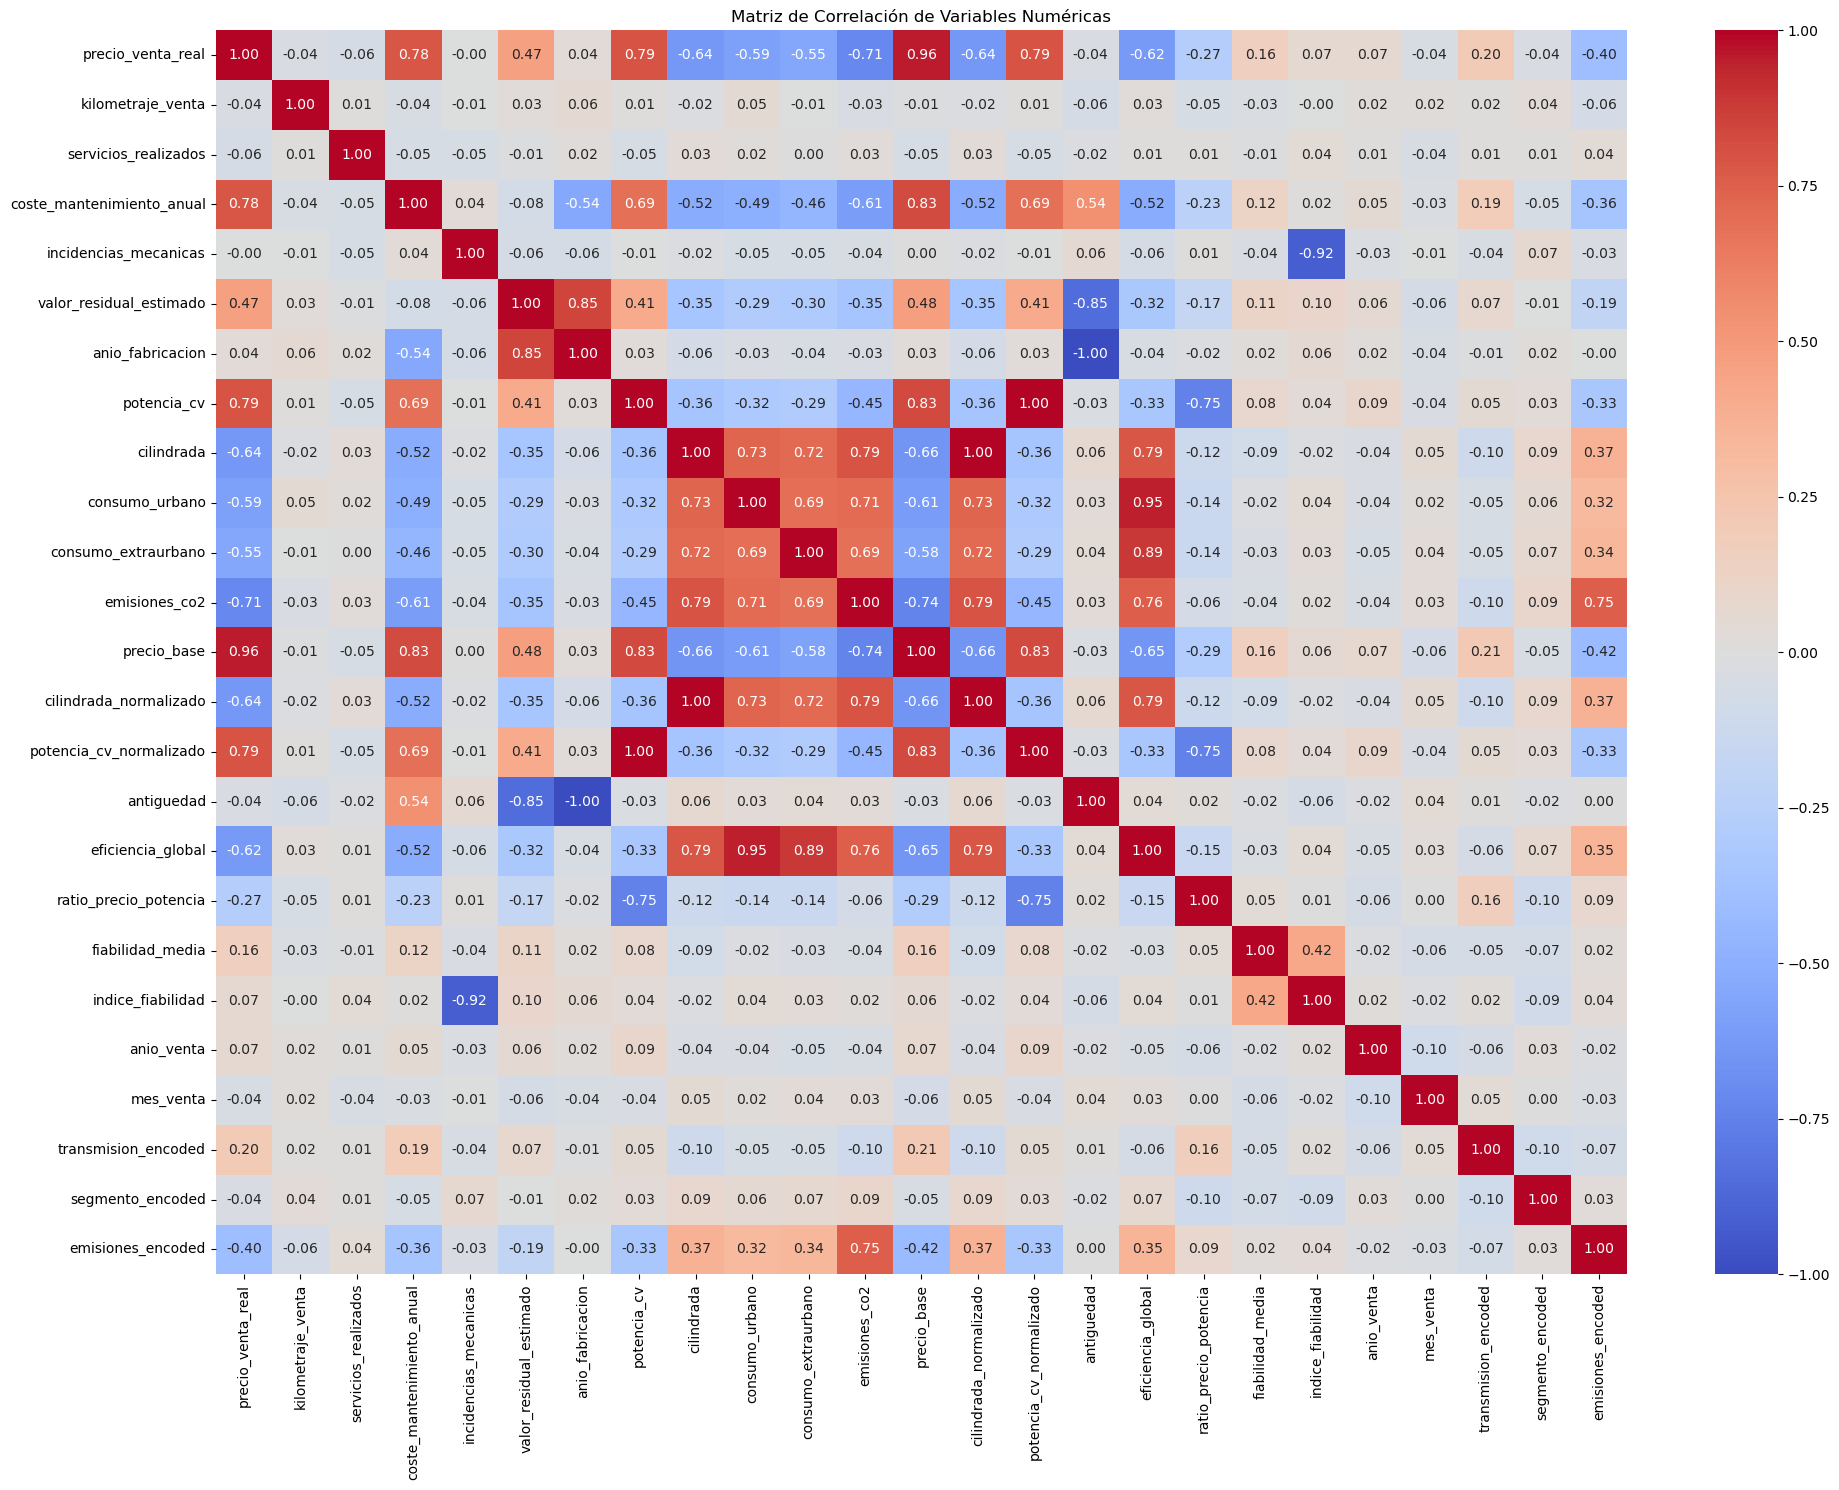

In [34]:
#Matriz de correlación del dataframe de ventas y vehiculos
cols_ignore = ['venta_id', 'vehiculo_id', 'fecha_venta', 'marca', 'modelo', 'transmision', 'categoria_emisiones', 'segmento', 'recomendacion']

#Eliminamos las columnas no numéricas o irrelevantes
df_matrix = df_corr.drop(columns=cols_ignore, errors='ignore').select_dtypes(include=[np.number])

plt.figure(figsize=(20,15))
sns.heatmap(df_matrix.corr(), annot=True, fmt=".2f", cmap='coolwarm', vmax=1, vmin=-1)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.tight_layout()
plt.show()

In [31]:
#Dataframes con los que trabajaremos en la parte de modelado
df_modelado_ventas = df.copy()
df_modelado_opiniones = df_opiniones.copy()

### Fase 3: Minería de Datos (KDD)